# Bug and Corrections notebook 

## Imports 

In [1]:
import pandas as pd
import logging
import sys
import numpy as np
from dataclasses import asdict
from pathlib import Path

sys.path.append(r"C:\Users\giuli\Repositories\intraday-momentum\src")
path = "/home/corwyn/Black_swan/Intraday_project/intraday-momentum"
sys.path.append("/home/corwyn/Black_swan/Intraday_project/intraday-momentum/src")
from classes.metrics.metrics import MetricsCalculator
from classes.backtest.engine import BacktestEngine  
from classes.backtest.default import BacktestDefaults 

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,   # <-- allow printing in jupyter notebooks
)

logger = logging.getLogger(__name__)


In [2]:
root = path

df_spy = pd.read_csv(root + "/data/cleaned/spy_1min_2008_2021_cleaned.csv")
df_dividends = pd.read_csv(root + "/data/cleaned/SPY_dividends_2022-05-09_2024-04-22.csv")
df_spy_daily = pd.read_pickle(root + "/data/cleaned/daily_sp500.pkl")

# Print information about the dataframes
df_spy.info()
print("\n")
df_dividends.info()
print("\n")
df_spy_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2070834 entries, 0 to 2070833
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   open      float64
 2   high      float64
 3   low       float64
 4   close     float64
 5   volume    int64  
 6   barCount  int64  
 7   average   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 126.4+ MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cash_amount       8 non-null      float64
 1   currency          8 non-null      object 
 2   declaration_date  8 non-null      object 
 3   dividend_type     8 non-null      object 
 4   ex_dividend_date  8 non-null      object 
 5   frequency         8 non-null      int64  
 6   id                8 non-null      object 
 7   pay_date          8 non-null      object 
 8   record_date     

In [3]:
df_spy.set_index("date", inplace=True)
df_spy.index = pd.to_datetime(df_spy.index)


In [4]:
df_spy

,open,high,low,close,volume,barCount,average
date,,,,,,,
2008-01-22 07:30:00,126.45,126.82,126.00,126.67,30987,4541,126.283
2008-01-22 07:31:00,126.67,127.17,126.39,127.12,20111,3125,126.958
2008-01-22 07:32:00,127.10,127.13,126.71,126.78,11979,2074,126.922
2008-01-22 07:33:00,126.76,126.90,126.53,126.54,8017,1350,126.675
2008-01-22 07:34:00,126.54,127.18,126.54,126.78,11967,1253,126.730
...,...,...,...,...,...,...,...
2021-05-06 13:55:00,418.56,418.77,418.48,418.49,9073,4584,418.660
2021-05-06 13:56:00,418.50,418.73,418.47,418.64,6680,3095,418.622
2021-05-06 13:57:00,418.64,418.79,418.63,418.79,6912,2868,418.744


In [5]:
dfs = {
    "df_spy": df_spy,
    "df_spy_daily": df_spy_daily,
}

for name, df in dfs.items():
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{name}: index must be a DatetimeIndex.")
    else:
        logger.info(f"{name}: index is a valid DatetimeIndex with timezone={df.index.tz}.")


2025-12-11 17:57:26,549 | INFO | df_spy: index is a valid DatetimeIndex with timezone=None.
2025-12-11 17:57:26,554 | INFO | df_spy_daily: index is a valid DatetimeIndex with timezone=UTC.


### Dividends

In [6]:
# Make a copy
df_dividends_prepared = df_dividends.copy()

# Rename columns to match what MetricsCalculator expects
df_dividends_prepared = df_dividends_prepared.rename(columns={
    "ex_dividend_date": "caldt",  # Metrics expects 'caldt'
    "cash_amount": "dividend"     # Metrics expects 'dividend'
})

# Convert 'caldt' to datetime
df_dividends_prepared["caldt"] = pd.to_datetime(df_dividends_prepared["caldt"])

# Keep only the necessary columns
df_dividends_prepared = df_dividends_prepared[["caldt", "dividend", "ticker"]]

# Verify
print(df_dividends_prepared.head())
print(df_dividends_prepared.columns)

       caldt  dividend ticker
0 2023-12-15  1.906073    SPY
1 2023-09-15  1.583169    SPY
2 2023-06-16  1.638367    SPY
3 2023-03-17  1.506204    SPY
4 2024-12-20  1.965548    SPY
Index(['caldt', 'dividend', 'ticker'], dtype='object')


### Metrics

In [7]:
# Check
df_spy.drop(columns =["barCount", "average"], inplace = True)

In [8]:
print(df_spy.tail())

                       open    high     low   close  volume
date                                                       
2021-05-06 13:55:00  418.56  418.77  418.48  418.49    9073
2021-05-06 13:56:00  418.50  418.73  418.47  418.64    6680
2021-05-06 13:57:00  418.64  418.79  418.63  418.79    6912
2021-05-06 13:58:00  418.79  418.83  418.71  418.76    7891
2021-05-06 13:59:00  418.76  419.21  418.76  419.08   18343


to check this thing we need to plot by hand the lower bound upper bound and check if they make any sense 

Recall 

$$
\text{UpperBound}_{t,\mathrm{HH:MM}}
= \text{Open}_{t,9:30} \times \left( 1 + \sigma_{t,9:30 - \mathrm{HH:MM}} \right)
$$

$$
\text{LowerBound}_{t,\mathrm{HH:MM}}
= \text{Open}_{t,9:30} \times \left( 1 - \sigma_{t,9:30 - \mathrm{HH:MM}} \right)
$$


In [13]:
df_spy.index = pd.to_datetime(df_spy.index)
df_spy = df_spy.sort_index()

df_spy["day"] = df_spy.index.normalize()  # midnight timestamps

# Get first timestamp per day and expand to all rows in that day
first_ts_per_day = df_spy.groupby("day").apply(lambda x: x.index[0], include_groups=False)
first_ts = df_spy["day"].map(first_ts_per_day)

df_spy["minute_of_day"] = ((df_spy.index - first_ts).dt.total_seconds() // 60).astype(int)

open_930_per_day = (
    df_spy.groupby("day").first()["open"]
)

df_spy["open_at_930"] = df_spy["day"].map(open_930_per_day)

df_spy["move"] = (df_spy["close"] / df_spy["open_at_930"] - 1).abs()

agg = (
    df_spy.groupby(["day", "minute_of_day"])
          .agg(move=("move", "last"))
          .reset_index()
)
agg = agg.sort_values(["minute_of_day", "day"])

agg["sigma"] = (
    agg.groupby("minute_of_day")["move"]
       .rolling(14, min_periods=2)
       .mean()
       .reset_index(level=0, drop=True)
)

df_spy = df_spy.merge(
    agg[["day", "minute_of_day", "sigma"]],
    on=["day", "minute_of_day"],
    how="left"
)

# Get last close per day and shift to get previous day's close
last_close_per_day = df_spy.groupby("day")["close"].last()
prev_close_per_day = last_close_per_day.shift(1)
df_spy["prev_close"] = df_spy["day"].map(prev_close_per_day)

df_spy["open_ref"] = df_spy[["open_at_930","prev_close"]].max(axis=1)
df_spy["low_ref"]  = df_spy[["open_at_930","prev_close"]].min(axis=1)

df_spy["upper_bnd"] = df_spy["open_ref"] * (1 + df_spy["sigma"])
df_spy["lower_bnd"] = df_spy["low_ref"]  * (1 - df_spy["sigma"])


In [16]:
df_spy.tail()

,open,high,low,close,volume,day,minute_of_day,open_at_930,move,sigma,prev_close,open_ref,low_ref,upper_bnd,lower_bnd
1970-01-01 00:00:00.002070829,418.56,418.77,418.48,418.49,9073,2021-05-06,385,415.82,0.006421,0.004257,415.73,415.82,415.73,417.589961,413.960422
1970-01-01 00:00:00.002070830,418.50,418.73,418.47,418.64,6680,2021-05-06,386,415.82,0.006782,0.004232,415.73,415.82,415.73,417.579620,413.970760
1970-01-01 00:00:00.002070831,418.64,418.79,418.63,418.79,6912,2021-05-06,387,415.82,0.007143,0.004203,415.73,415.82,415.73,417.567822,413.982556
1970-01-01 00:00:00.002070832,418.79,418.83,418.71,418.76,7891,2021-05-06,388,415.82,0.007070,0.004139,415.73,415.82,415.73,417.541159,414.009214
1970-01-01 00:00:00.002070833,418.76,419.21,418.76,419.08,18343,2021-05-06,389,415.82,0.007840,0.003964,415.73,415.82,415.73,417.468150,414.082207


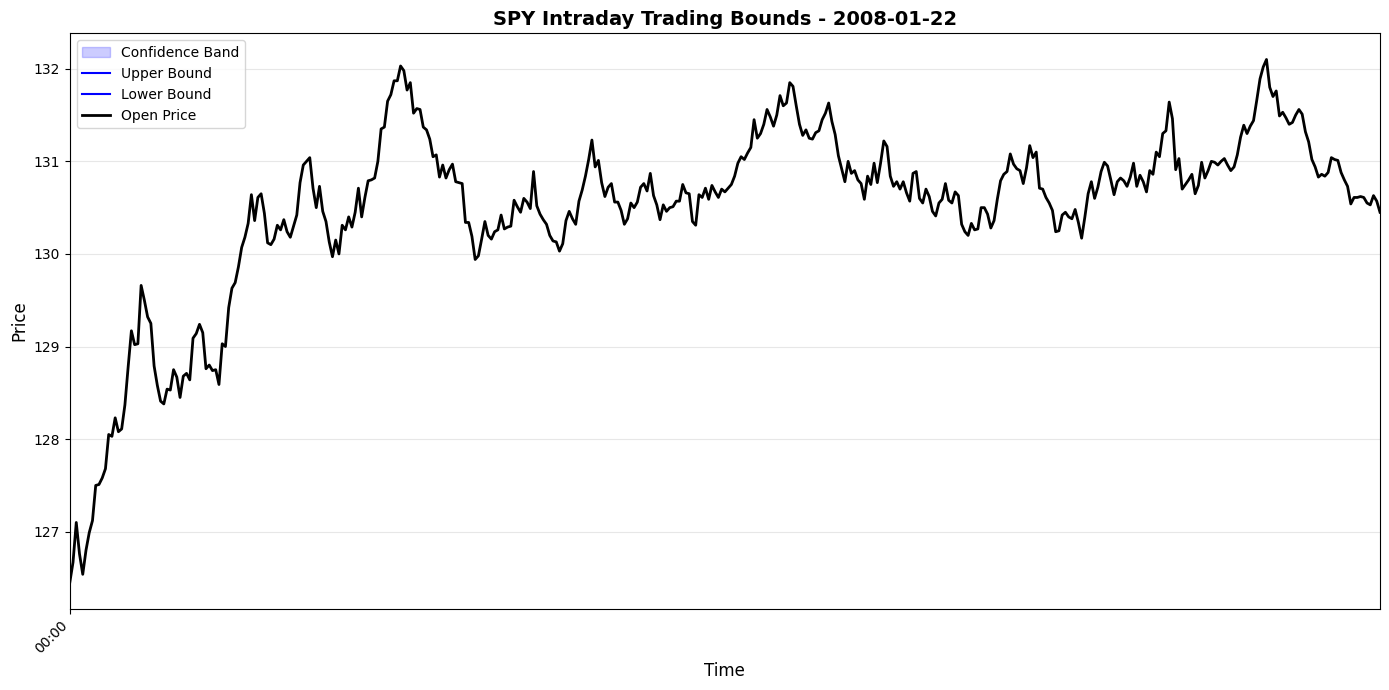

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import pandas as pd
import os

# Choose target date (change as needed) - data ranges from 2008-01-22 to 2021-05-06
target_date = '2008-01-22'
target_date_dt = pd.to_datetime(target_date)

# Ensure index is datetime
df_spy.index = pd.to_datetime(df_spy.index)

# Filter by the 'day' column instead of the index
df_day = df_spy[df_spy["day"] == target_date_dt].copy()

if df_day.empty:
    print(f"No intraday data for {target_date}")
    print(f"Available date range: {df_spy['day'].min()} to {df_spy['day'].max()}")
else:
    # Set a clean datetime index for matplotlib (use the index which is already datetime)
    if getattr(df_day.index, 'tz', None) is not None:
        try:
            df_day.index = df_day.index.tz_convert(None)
        except Exception:
            try:
                df_day.index = df_day.index.tz_localize(None)
            except Exception:
                pass

    # Create plot
    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot the band with transparency
    ax.fill_between(df_day.index, df_day["lower_bnd"], df_day["upper_bnd"], 
                    alpha=0.2, color='blue', label='Confidence Band')

    # Plot upper and lower bounds
    ax.plot(df_day.index, df_day["upper_bnd"], color='blue', linewidth=1.5, label='Upper Bound')
    ax.plot(df_day.index, df_day["lower_bnd"], color='blue', linewidth=1.5, label='Lower Bound')

    # Plot open price
    ax.plot(df_day.index, df_day["open"], color='black', linewidth=2, label='Open Price')

    # Plot VWAP as dashed line if present
    if "vwap" in df_day.columns:
        ax.plot(df_day.index, df_day["vwap"], color='red', linewidth=2, label='VWAP', linestyle='--')

    # Create explicit major (hourly) and minor (30min) ticks using pandas date_range
    start = df_day.index[0].floor('h')
    end = df_day.index[-1].ceil('h')
    major_ticks = pd.date_range(start=start, end=end, freq='60min')
    minor_ticks = pd.date_range(start=start, end=end, freq='30min')

    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)
    ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))

    # Tight x-limits and formatting
    ax.set_xlim([df_day.index[0], df_day.index[-1]])
    plt.xticks(rotation=45, ha='right')

    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title(f'SPY Intraday Trading Bounds - {target_date}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()


### Backtests

The columns we need are these ones : 

["day", "open", "close", "vwap", "sigma_open", "spy_dvol", "min_from_open","dividends"]

In [ ]:

defaults = BacktestDefaults(
    minute_path=path + "/notebooks/data/processed/df_all_days.pkl",
    daily_path= path + "/notebooks/data/processed/df_daily_groups.pkl",
    initial_aum=100_000.0,
    commission_rate=0.0035,
    min_comm_per_order=0.35,
    slippage_bps=0,
    band_mult=1.0,
    trade_freq=30,
    sizing_type="full_notional",
    target_vol=0.02,
    max_leverage=4.0, #Warning should be 2.0 in Quantconnect
)

engine = BacktestEngine()
trade_log_df, daily_pnl_df, equity_curve_df = engine.run_backtest(asdict(defaults))

[WARNING] Daily data at '/home/corwyn/Black_swan/Intraday_project/intraday-momentum/notebooks/data/processed/df_daily_groups.pkl' is missing required columns: 'caldt' and/or 'close'.


2025-12-10 23:20:37,972 | INFO | Trade log saved to /home/corwyn/Black_swan/Intraday_project/intraday-momentum/src/data/processed/trade_log.csv
2025-12-10 23:20:37,973 | INFO | Daily PnL saved to /home/corwyn/Black_swan/Intraday_project/intraday-momentum/src/data/processed/daily_pnl.pkl


In [ ]:
from classes.viz.plotter import Plotter
df = pd.read_pickle(path + "/src/data/processed/daily_pnl.pkl")
df.index = pd.to_datetime(df.index)

In [ ]:
df

,AUM,ret,gross_pnl,commission,slippage_cost,net_pnl,ret_spy
day,,,,,,,
2023-12-26,99904.8390,-0.000952,-90.7089,4.431,0.0,-95.1399,NaN
2023-12-27,99904.8390,0.000000,0.0000,0.000,0.0,0.0000,NaN
2023-12-28,99904.8390,0.000000,0.0000,0.000,0.0,0.0000,NaN
2023-12-29,99987.3690,0.000826,81.9630,1.470,0.0,80.4930,NaN
2024-01-02,99987.3690,0.000000,0.0000,0.000,0.0,0.0000,NaN
...,...,...,...,...,...,...,...
2024-04-16,102921.0092,0.000000,0.0000,0.000,0.0,0.0000,NaN
2024-04-17,102651.6282,-0.002617,-261.8700,1.421,0.0,-263.2910,NaN
2024-04-18,102651.6282,0.000000,0.0000,0.000,0.0,0.0000,NaN


2025-12-10 23:20:38,019 | INFO | Dataframe correctly initialized
2025-12-10 23:20:38,021 | INFO | Computing comulative AUM for SPY
2025-12-10 23:20:38,234 | ERROR | Failed to save plot to /home/corwyn/Black_swan/Intraday_project/intraday-momentum/ouputs/figures/test_01.jpg: [Errno 2] No such file or directory: '/home/corwyn/Black_swan/Intraday_project/intraday-momentum/ouputs/figures/test_01.jpg'


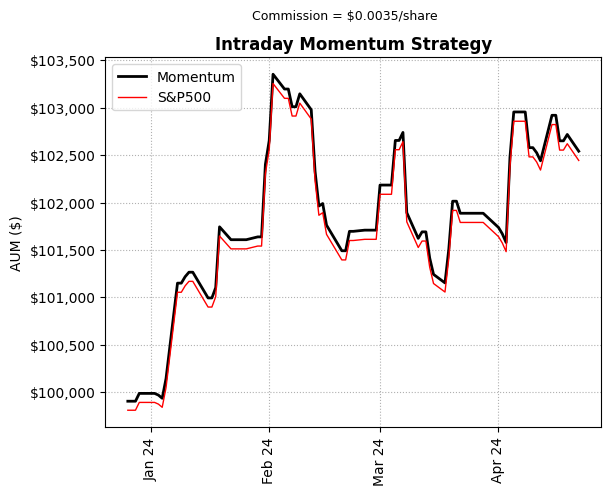

In [ ]:

plott = Plotter(df)
# Use actual starting AUM to avoid ValueError
start_aum = df["AUM"].iloc[0]
plott.plot_cum_returns("ret", "AUM",path + "/ouputs/figures/test_01.jpg", AUM_0=start_aum)

In [ ]:
plott.compute_statistics("ret", "AUM", 0.000107 )

2025-12-10 23:20:38,339 | INFO | Computing returns and performance statistics such as Sharpe, Hit, Drawdown)


,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Hit Ratio (%),Maximum Drawdown (%)
Value,3.0,8.1,4.5,1.15,49.0,2.0
